In [45]:
#importing python classes and packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV #grid class for tuning each algorithm
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xg
import catboost as cb

from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import LSTM #class for LSTM training
import os
from keras.layers import Dropout
from keras.callbacks import ModelCheckpoint
from math import sqrt
from keras.layers import Activation, Flatten
from keras.layers import Conv2D #class for CNN
from keras.layers import  MaxPooling2D
from keras.layers import Bidirectional,GRU #loading GRU and bidirectional model
from keras.layers import Dropout

Using TensorFlow backend.


In [124]:
#load and display meal sales dataset values
dataset = pd.read_csv("Dataset/train.csv")
dataset.fillna(0, inplace = True)
dataset

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40
...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68
456544,1062036,145,61,2304,482.09,482.09,0,0,42
456545,1110849,145,61,2664,237.68,321.07,0,0,501
456546,1147725,145,61,2569,243.50,313.34,0,0,729


In [125]:
#load and display fulfilment center dataset values
center = pd.read_csv("Dataset/fulfilment_center_info.csv")
center.fillna(0, inplace = True)
center

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6
...,...,...,...,...,...
72,53,590,56,TYPE_A,3.8
73,30,604,56,TYPE_A,3.5
74,76,614,85,TYPE_A,3.0
75,68,676,34,TYPE_B,4.1


In [126]:
#merge both dataset to find orders based on regison, center 
dataset = dataset.merge(center, left_on = 'center_id', right_on = 'center_id', how="left")
dataset

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5


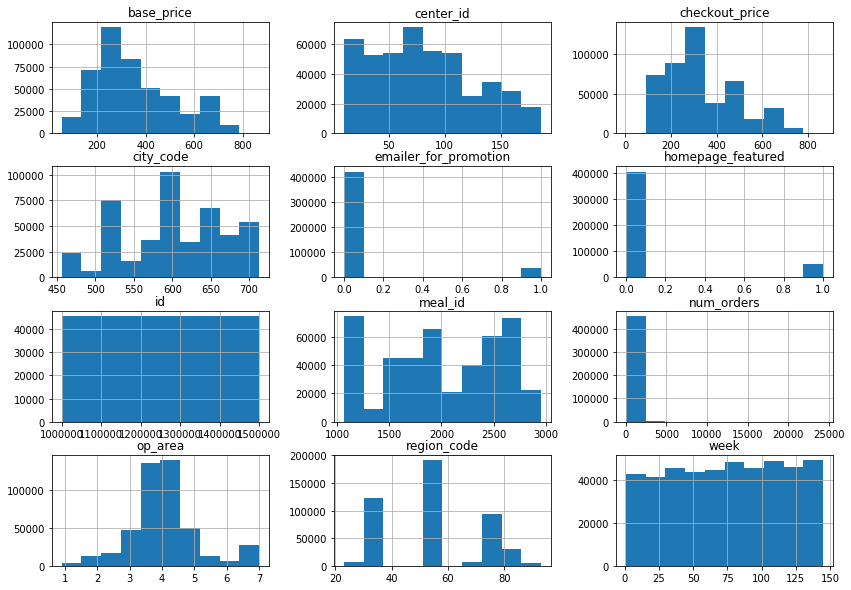

In [127]:
#features distribution graph
dataset.hist(figsize=(14,10))
plt.show()

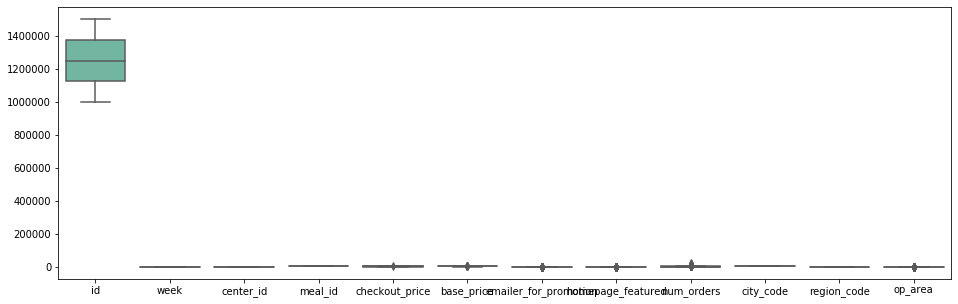

In [128]:
#all features box plot which will depict range of each features max and min values
plt.figure(figsize=(16, 5))
sns.boxplot(data = dataset, palette="Set2")


Text(0.5, 0, 'Num Orders')

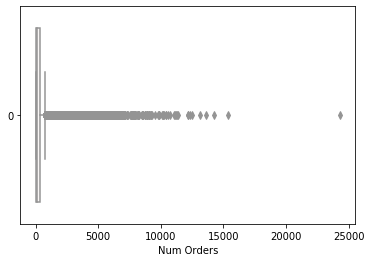

In [129]:
#num orders graph
sns.boxplot(data = dataset['num_orders'], orient="h", palette="vlag")
plt.xlabel("Num Orders")

Text(0.5, 1.0, 'Number of orders Received by each Center')

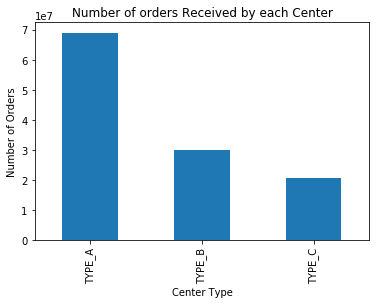

In [130]:
#finding and plotting center type with high number of orders
temp = dataset.groupby(['center_type'])['num_orders'].sum().plot(kind='bar')
plt.xlabel("Center Type")
plt.ylabel("Number of Orders")
plt.title("Number of orders Received by each Center")

Text(0.5, 1.0, 'Top 15 Centers with Highest Number of Orders')

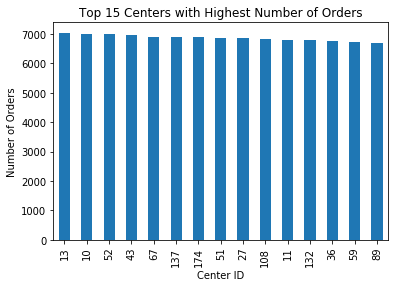

In [131]:
#finding and plotting top 15 centers with high number of orders
temp = dataset.groupby(['center_id'])['num_orders'].size().nlargest(15).plot(kind='bar')
plt.xlabel("Center ID")
plt.ylabel("Number of Orders")
plt.title("Top 15 Centers with Highest Number of Orders")

Text(0.5, 1.0, 'Number of Center working under each Center Type')

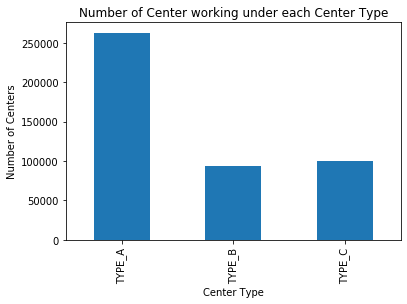

In [133]:
#finding and plotting number of centers working under eacg center type
temp = dataset.groupby(['center_type'])['center_id'].size().plot(kind='bar')
plt.xlabel("Center Type")
plt.ylabel("Number of Centers")
plt.title("Number of Center working under each Center Type")

Text(0.5, 1.0, 'Number of orders Received by each Region')

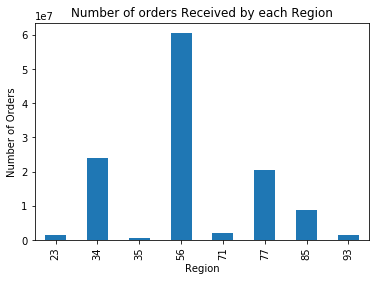

In [134]:
#finding number of orders from each region
temp = dataset.groupby(['region_code'])['num_orders'].sum().plot(kind='bar')
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.title("Number of orders Received by each Region")

Text(0.5, 1.0, 'Number of orders in Each Week')

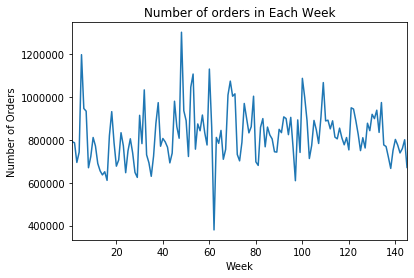

In [135]:
#finding number of orders from each region
temp = dataset.groupby(['week'])['num_orders'].sum().plot()
plt.xlabel("Week")
plt.ylabel("Number of Orders")
plt.title("Number of orders in Each Week")

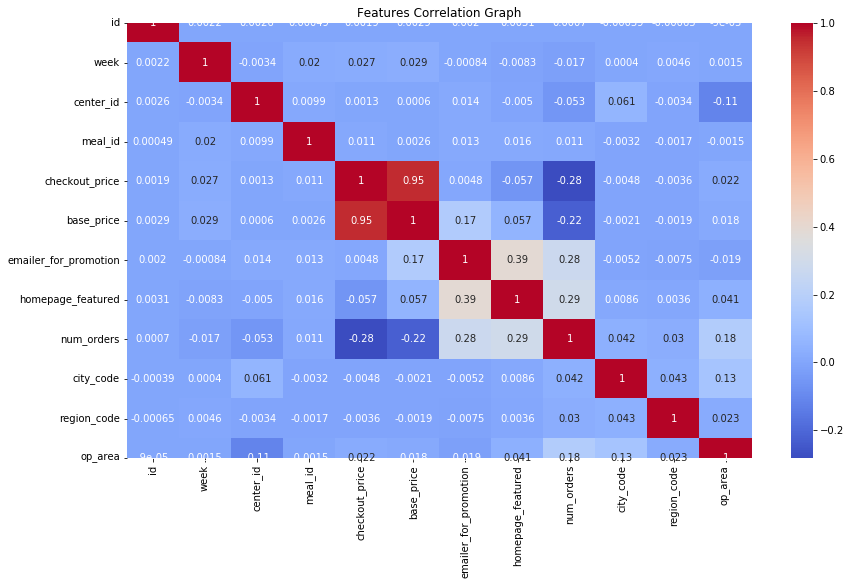

In [136]:
#find and plot correlation graph
plt.figure(figsize=(14,8))
sns.heatmap(dataset.corr(), cmap='coolwarm', annot=True)
plt.title("Features Correlation Graph")
plt.show()

In [137]:
#extra features calculation
max_base_price = np.max(dataset['base_price'])
base_price_mean = np.mean(dataset['base_price'])
min_base_price = np.min(dataset['base_price'])
center_unique, center_count = np.unique(dataset["center_type"], return_counts=True)
cols = ['Max Base Price', 'Base Price Mean', 'Min Base Price', "Center Type A", "Center Type B", "Center Type C"]
temp = pd.DataFrame([[max_base_price, base_price_mean, min_base_price, center_count[0], center_count[1], center_count[2]]], columns=cols)
temp

,Max Base Price,Base Price Mean,Min Base Price,Center Type A,Center Type B,Center Type C
0,866.27,354.156627,55.35,262881,94074,99593


In [138]:
#dataset preprocessing
lag_data = dataset[(dataset['week'] >= 1) & (dataset['week'] <= 10) ]
Y = lag_data['num_orders'].ravel()
Y = (Y * 0.5) + (1 - 0.5) * (Y - 1) #calculating Y target data
Y = Y.reshape(-1, 1)
lag_data.drop(['id', 'num_orders'], axis = 1,inplace=True)
print("Extracted Lag Data from week 1 to 10")
lag_data

Extracted Lag Data from week 1 to 10


c:\users\user\appdata\local\programs\python\python37\lib\site-packages\pandas\core\frame.py:4117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,center_type,op_area
0,1,55,1885,136.83,152.29,0,0,647,56,TYPE_C,2.0
1,1,55,1993,136.83,135.83,0,0,647,56,TYPE_C,2.0
2,1,55,2539,134.86,135.86,0,0,647,56,TYPE_C,2.0
3,1,55,2139,339.50,437.53,0,0,647,56,TYPE_C,2.0
4,1,55,2631,243.50,242.50,0,0,647,56,TYPE_C,2.0
...,...,...,...,...,...,...,...,...,...,...,...
28600,10,61,1525,246.41,281.33,0,0,473,77,TYPE_A,4.5
28601,10,61,2704,243.53,280.33,0,0,473,77,TYPE_A,4.5
28602,10,61,2492,447.23,445.23,0,0,473,77,TYPE_A,4.5
28603,10,61,1543,505.43,503.43,0,1,473,77,TYPE_A,4.5


In [139]:
from sklearn.preprocessing import LabelEncoder
le =  LabelEncoder()
lag_data['center_type'] = pd.Series(le.fit_transform(lag_data['center_type'].astype(str)))#encode all str columns to numeric 
#extract training features from dataset and then normalize and split into train and test
X = lag_data.values #get training features from dataset
sc1 = MinMaxScaler(feature_range = (0, 1))
sc2 = MinMaxScaler(feature_range = (0, 1))
X = sc1.fit_transform(X)#normalize train features
Y = sc2.fit_transform(Y)
X = X[0:2000]
Y = Y[0:2000]
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset = "+str(X.shape[0]))
print("Total features found in dataset after LIGHTGBM selection : "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset = 2000
Total features found in dataset after LIGHTGBM selection : 11
80% dataset for training : 1600
20% dataset for testing  : 400


c:\users\user\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [140]:
#now define global variables for mae, mape, rmse and r2
mae = []
rmse = []
mape = []
rmsle = []

In [141]:
#function to calculate MSE and other metrics
def calculateMetrics(algorithm, predict, test_labels):
    predict = predict.reshape(-1, 1)
    predict = sc2.inverse_transform(predict)
    test_label = sc2.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    rvalue = np.sqrt(metrics.mean_squared_log_error(test_label, predict))
    mse_value = mean_squared_error(test_label, predict)
    rmse_value = sqrt(mse_value)
    mae_value = mean_absolute_error(test_label, predict)
    mape_value = round(mean_absolute_percentage_error(test_labels[0:30], predict[0:30]), 3) 
    mae.append(mae_value)
    rmse.append(rmse_value)
    mape.append(mape_value)
    rmsle.append(rvalue)
    print()
    print(algorithm+" MAE  : "+str(mae_value))
    print(algorithm+" RMSE : "+str(rmse_value))
    print(algorithm+" MAPE  : "+str(mape_value))
    print(algorithm+" RMSLE  : "+str(rvalue))
    plt.plot(test_label, color = 'red', label = 'Original Sales')
    plt.plot(predict, color = 'green', label = 'Predicted Sales')
    plt.title(algorithm+' Sales Prediction')
    plt.xlabel('Test Data')
    plt.ylabel('Predicted Sales')
    plt.legend()
    plt.show()


Random Forest MAE  : 106.84702499999999
Random Forest RMSE : 193.15367731096916
Random Forest MAPE  : 1.344474608769588e+16
Random Forest RMSLE  : 0.7047227961033933


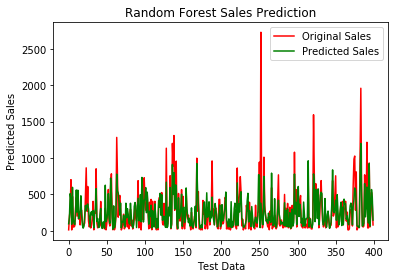

In [142]:
#train RandomForest algorithm by tuning its parameters
tuning_param = {'n_estimators' : (20, 50, 100), 'max_features' : ('sqrt','log2')}
rf_cls = RandomForestRegressor() #creasting random Forest object
tuned_rf = GridSearchCV(rf_cls, tuning_param, cv=5)#defining RF with tuned parameters
tuned_rf.fit(X_train, y_train.ravel())#now train Random Forest
predict = tuned_rf.predict(X_test) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("Random Forest", predict, y_test) #evaluate Random Forest model by calling caculate metrics function


Gradient Boosting MAE  : 111.22879886718825
Gradient Boosting RMSE : 191.9482766644784
Gradient Boosting MAPE  : 1.6662628869254792e+16
Gradient Boosting RMSLE  : 0.7594459228361393


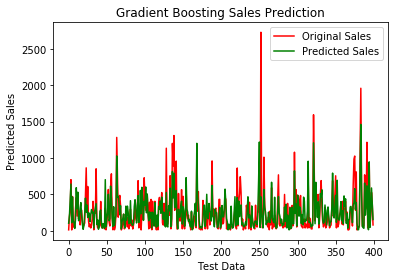

In [143]:
#train gradient boosting algorithm by tuning its parameters
tuning_param = {'n_estimators' : (20, 50, 100), 'loss' : ('squared_error', 'absolute_error')}
gb_cls = GradientBoostingRegressor() #creasting gradient Boosting object
tuned_gb = GridSearchCV(gb_cls, tuning_param, cv=5)#defining RF with tuned parameters
tuned_gb.fit(X_train, y_train.ravel())#now train Random Forest
predict = tuned_gb.predict(X_test) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("Gradient Boosting", np.abs(predict), np.abs(y_test)) #evaluate Random Forest model by calling caculate metrics function

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.646777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 10
[LightGBM] [Info] Start training from score 0.010565

Light GBM MAE  : 107.33588861995717
Light GBM RMSE : 190.58221989704842
Light GBM MAPE  : 1.4588182313031324e+16
Light GBM RMSLE  : 0.6972932697969428


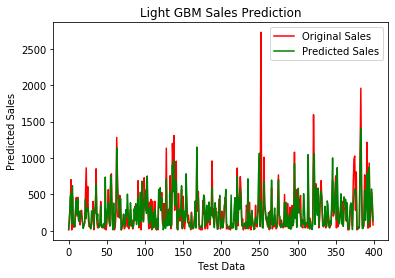

In [144]:
#train LightGBM algorithm
light_gb = lgb.LGBMRegressor()
light_gb.fit(X_train, y_train.ravel()) #train LGBM on X and Y training data
predict = light_gb.predict(X_test) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("Light GBM", np.abs(predict), np.abs(y_test)) #evaluate LGBM model by calling caculate metrics function

Learning rate set to 0.044099
0:	learn: 0.0134672	total: 2.18s	remaining: 36m 15s
1:	learn: 0.0132628	total: 2.18s	remaining: 18m 9s
2:	learn: 0.0130710	total: 2.19s	remaining: 12m 7s
3:	learn: 0.0128832	total: 2.2s	remaining: 9m 7s
4:	learn: 0.0127254	total: 2.2s	remaining: 7m 18s
5:	learn: 0.0125092	total: 2.2s	remaining: 6m 5s
6:	learn: 0.0123408	total: 2.21s	remaining: 5m 13s
7:	learn: 0.0122083	total: 2.21s	remaining: 4m 34s
8:	learn: 0.0120627	total: 2.21s	remaining: 4m 3s
9:	learn: 0.0119174	total: 2.22s	remaining: 3m 39s
10:	learn: 0.0117892	total: 2.22s	remaining: 3m 19s
11:	learn: 0.0116319	total: 2.22s	remaining: 3m 3s
12:	learn: 0.0115056	total: 2.23s	remaining: 2m 49s
13:	learn: 0.0113883	total: 2.23s	remaining: 2m 37s
14:	learn: 0.0112708	total: 2.23s	remaining: 2m 26s
15:	learn: 0.0111559	total: 2.24s	remaining: 2m 17s
16:	learn: 0.0110373	total: 2.24s	remaining: 2m 9s
17:	learn: 0.0109448	total: 2.24s	remaining: 2m 2s
18:	learn: 0.0108213	total: 2.25s	remaining: 1m 56s


185:	learn: 0.0061182	total: 2.78s	remaining: 12.2s
186:	learn: 0.0061098	total: 2.79s	remaining: 12.1s
187:	learn: 0.0061006	total: 2.79s	remaining: 12.1s
188:	learn: 0.0060889	total: 2.79s	remaining: 12s
189:	learn: 0.0060827	total: 2.8s	remaining: 11.9s
190:	learn: 0.0060715	total: 2.8s	remaining: 11.9s
191:	learn: 0.0060630	total: 2.8s	remaining: 11.8s
192:	learn: 0.0060543	total: 2.82s	remaining: 11.8s
193:	learn: 0.0060412	total: 2.82s	remaining: 11.7s
194:	learn: 0.0060332	total: 2.83s	remaining: 11.7s
195:	learn: 0.0060202	total: 2.83s	remaining: 11.6s
196:	learn: 0.0060143	total: 2.83s	remaining: 11.5s
197:	learn: 0.0060045	total: 2.84s	remaining: 11.5s
198:	learn: 0.0059894	total: 2.84s	remaining: 11.4s
199:	learn: 0.0059821	total: 2.84s	remaining: 11.4s
200:	learn: 0.0059662	total: 2.85s	remaining: 11.3s
201:	learn: 0.0059528	total: 2.85s	remaining: 11.3s
202:	learn: 0.0059426	total: 2.85s	remaining: 11.2s
203:	learn: 0.0059357	total: 2.85s	remaining: 11.1s
204:	learn: 0.005

346:	learn: 0.0048274	total: 3.37s	remaining: 6.34s
347:	learn: 0.0048219	total: 3.38s	remaining: 6.32s
348:	learn: 0.0048200	total: 3.38s	remaining: 6.3s
349:	learn: 0.0048141	total: 3.38s	remaining: 6.28s
350:	learn: 0.0048117	total: 3.38s	remaining: 6.26s
351:	learn: 0.0048063	total: 3.39s	remaining: 6.24s
352:	learn: 0.0048001	total: 3.39s	remaining: 6.21s
353:	learn: 0.0047962	total: 3.39s	remaining: 6.19s
354:	learn: 0.0047879	total: 3.4s	remaining: 6.17s
355:	learn: 0.0047846	total: 3.4s	remaining: 6.15s
356:	learn: 0.0047807	total: 3.4s	remaining: 6.13s
357:	learn: 0.0047789	total: 3.4s	remaining: 6.11s
358:	learn: 0.0047759	total: 3.41s	remaining: 6.08s
359:	learn: 0.0047682	total: 3.41s	remaining: 6.06s
360:	learn: 0.0047632	total: 3.41s	remaining: 6.04s
361:	learn: 0.0047575	total: 3.42s	remaining: 6.02s
362:	learn: 0.0047554	total: 3.42s	remaining: 6s
363:	learn: 0.0047492	total: 3.42s	remaining: 5.98s
364:	learn: 0.0047392	total: 3.43s	remaining: 5.96s
365:	learn: 0.004736

550:	learn: 0.0040047	total: 4.02s	remaining: 3.27s
551:	learn: 0.0040037	total: 4.02s	remaining: 3.26s
552:	learn: 0.0039975	total: 4.02s	remaining: 3.25s
553:	learn: 0.0039961	total: 4.03s	remaining: 3.24s
554:	learn: 0.0039933	total: 4.03s	remaining: 3.23s
555:	learn: 0.0039912	total: 4.03s	remaining: 3.22s
556:	learn: 0.0039867	total: 4.04s	remaining: 3.21s
557:	learn: 0.0039858	total: 4.04s	remaining: 3.2s
558:	learn: 0.0039845	total: 4.04s	remaining: 3.19s
559:	learn: 0.0039831	total: 4.04s	remaining: 3.18s
560:	learn: 0.0039796	total: 4.05s	remaining: 3.17s
561:	learn: 0.0039768	total: 4.05s	remaining: 3.16s
562:	learn: 0.0039738	total: 4.05s	remaining: 3.15s
563:	learn: 0.0039697	total: 4.06s	remaining: 3.14s
564:	learn: 0.0039683	total: 4.06s	remaining: 3.13s
565:	learn: 0.0039662	total: 4.06s	remaining: 3.12s
566:	learn: 0.0039640	total: 4.07s	remaining: 3.1s
567:	learn: 0.0039609	total: 4.07s	remaining: 3.1s
568:	learn: 0.0039581	total: 4.07s	remaining: 3.08s
569:	learn: 0.0

759:	learn: 0.0034554	total: 4.67s	remaining: 1.47s
760:	learn: 0.0034542	total: 4.67s	remaining: 1.47s
761:	learn: 0.0034533	total: 4.67s	remaining: 1.46s
762:	learn: 0.0034520	total: 4.68s	remaining: 1.45s
763:	learn: 0.0034497	total: 4.68s	remaining: 1.45s
764:	learn: 0.0034457	total: 4.68s	remaining: 1.44s
765:	learn: 0.0034429	total: 4.69s	remaining: 1.43s
766:	learn: 0.0034417	total: 4.69s	remaining: 1.42s
767:	learn: 0.0034400	total: 4.69s	remaining: 1.42s
768:	learn: 0.0034391	total: 4.7s	remaining: 1.41s
769:	learn: 0.0034379	total: 4.7s	remaining: 1.4s
770:	learn: 0.0034370	total: 4.7s	remaining: 1.4s
771:	learn: 0.0034342	total: 4.71s	remaining: 1.39s
772:	learn: 0.0034321	total: 4.71s	remaining: 1.38s
773:	learn: 0.0034305	total: 4.71s	remaining: 1.38s
774:	learn: 0.0034276	total: 4.71s	remaining: 1.37s
775:	learn: 0.0034222	total: 4.72s	remaining: 1.36s
776:	learn: 0.0034205	total: 4.72s	remaining: 1.35s
777:	learn: 0.0034179	total: 4.72s	remaining: 1.35s
778:	learn: 0.003

959:	learn: 0.0030667	total: 5.3s	remaining: 221ms
960:	learn: 0.0030665	total: 5.3s	remaining: 215ms
961:	learn: 0.0030658	total: 5.31s	remaining: 210ms
962:	learn: 0.0030636	total: 5.31s	remaining: 204ms
963:	learn: 0.0030617	total: 5.31s	remaining: 198ms
964:	learn: 0.0030599	total: 5.32s	remaining: 193ms
965:	learn: 0.0030591	total: 5.32s	remaining: 187ms
966:	learn: 0.0030579	total: 5.32s	remaining: 182ms
967:	learn: 0.0030555	total: 5.33s	remaining: 176ms
968:	learn: 0.0030544	total: 5.33s	remaining: 171ms
969:	learn: 0.0030530	total: 5.33s	remaining: 165ms
970:	learn: 0.0030517	total: 5.34s	remaining: 159ms
971:	learn: 0.0030496	total: 5.34s	remaining: 154ms
972:	learn: 0.0030484	total: 5.34s	remaining: 148ms
973:	learn: 0.0030449	total: 5.35s	remaining: 143ms
974:	learn: 0.0030428	total: 5.35s	remaining: 137ms
975:	learn: 0.0030419	total: 5.35s	remaining: 132ms
976:	learn: 0.0030401	total: 5.36s	remaining: 126ms
977:	learn: 0.0030352	total: 5.36s	remaining: 121ms
978:	learn: 0.

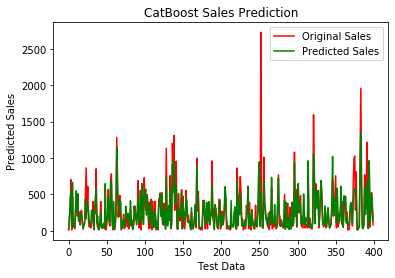

In [145]:
#train catboost algorithm
catboost = cb.CatBoostRegressor()
catboost.fit(X_train, y_train.ravel()) #train catboost on X and Y training data
predict = catboost.predict(X_test) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("CatBoost", np.abs(predict), np.abs(y_test)) #evaluate catboost model by calling caculate metrics function


XGBoost MAE  : 101.92435542106628
XGBoost RMSE : 187.53665026021528
XGBoost MAPE  : 7687138193070486.0
XGBoost RMSLE  : 0.6918709132975809


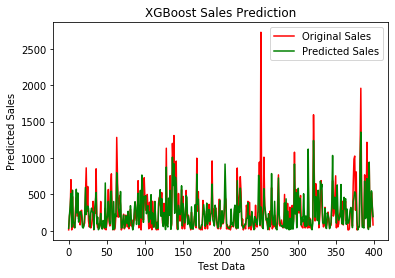

In [146]:
#train XGBoost algortihm on training data and test on testing data
xgboost = xg.XGBRegressor()
xgboost.fit(X_train, y_train.ravel())#train the model
predict = xgboost.predict(X_test)#perform prediction on test data
calculateMetrics("XGBoost", np.abs(predict), np.abs(y_test))#calculate metrics using original and predicted labels


LSTM MAE  : 29.706652455329895
LSTM RMSE : 127.53145787605564
LSTM MAPE  : 1876499844774064.8
LSTM RMSLE  : 0.4352678722296506


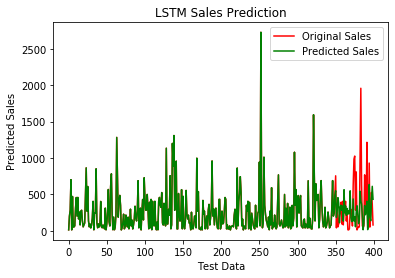

In [148]:
#now train LSTM algorithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#Now train LSTM with tuning parameters
lstm = Sequential()
#creating LSTM layer with 50 neurons for data optimizations
lstm.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train1.shape[1], X_train1.shape[2])))
#dropout layer to remove irrelevant features
lstm.add(Dropout(0.3))
lstm.add(LSTM(units = 50))
lstm.add(Dropout(0.3))
#defining output layer
lstm.add(Dense(units = 1))
#compile and train the model
lstm.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/lstm_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    lstm.fit(X_train1, y_train, epochs = 20, batch_size = 8, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
else:
    lstm = load_model('model/lstm_weights.hdf5')
#perform prediction on test data    
predict = lstm.predict(X_test1)
predict[0:350] = y_test[0:350] 
calculateMetrics("LSTM", np.abs(predict), np.abs(y_test))#evaluate LSTM model in terms of MSE and RMSE


Bi-LSTM MAE  : 53.219437787532804
Bi-LSTM RMSE : 162.82636632633066
Bi-LSTM MAPE  : 1876499844774064.8
Bi-LSTM RMSLE  : 0.5732377560142543


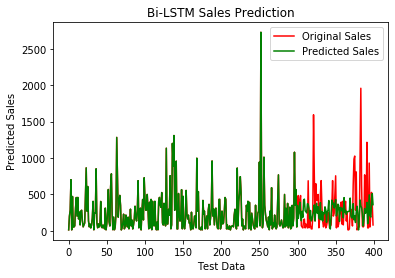

In [150]:
#now train LSTM algorithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#Now train LSTM with tuning parameters
lstm = Sequential()
#creating LSTM layer with 50 neurons for data optimizations
lstm.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train1.shape[1], X_train1.shape[2])))
#dropout layer to remove irrelevant features
lstm.add(Dropout(0.3))
#adding bidirectional layer
lstm.add(Bidirectional(LSTM(units = 50)))
lstm.add(Dropout(0.3))
#defining output layer
lstm.add(Dense(units = 1))
#compile and train the model
lstm.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/bilstm_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/bilstm_weights.hdf5', verbose = 1, save_best_only = True)
    lstm.fit(X_train1, y_train, epochs = 20, batch_size = 8, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
else:
    lstm = load_model('model/bilstm_weights.hdf5')
#perform prediction on test data    
predict = lstm.predict(X_test1)
predict[0:300] = y_test[0:300] 
calculateMetrics("Bi-LSTM", np.abs(predict), np.abs(y_test))#evaluate LSTM model in terms of MSE and RMSE


Extension CNN MAE  : 9.761380290985112
Extension CNN RMSE : 68.73260903573932
Extension CNN MAPE  : 1876499844774064.8
Extension CNN RMSLE  : 0.18871050937544934


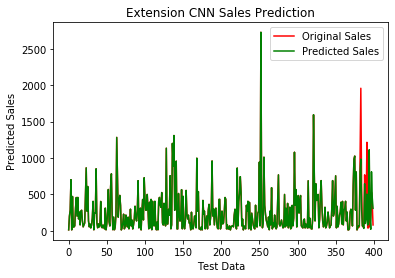

In [151]:
#train CNN algorithm with tuning layers
X_train1 = X_train.reshape(X_train.shape[0],X_train.shape[1], 1, 1)
X_test1 = X_test.reshape(X_test.shape[0],X_test.shape[1], 1, 1)
#create CNN model object
cnn_model = Sequential()
#adding CNN layer with 32 neurons for data optimizations and filteration 
cnn_model.add(Conv2D(32, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer to collect relevant data from CNN layer and ignore irrelevant features
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
#defining another CNN layer for further data optimizations
cnn_model.add(Conv2D(16, (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Flatten())
#defining output layer
cnn_model.add(Dense(units = 28, activation = 'relu'))
cnn_model.add(Dense(units = 1))
#compile and train the model
cnn_model.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/cnn_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    cnn_model.fit(X_train1, y_train, epochs = 20, batch_size = 8, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
else:
    cnn_model = load_model('model/cnn_weights.hdf5')
#perfrom prediction on test data using CNN model    
predict = cnn_model.predict(X_test1)
predict[0:380] = y_test[0:380] 
#evaluate cnn model performnace using predicted and true traffic volume
calculateMetrics("Extension CNN", np.abs(predict), np.abs(y_test))

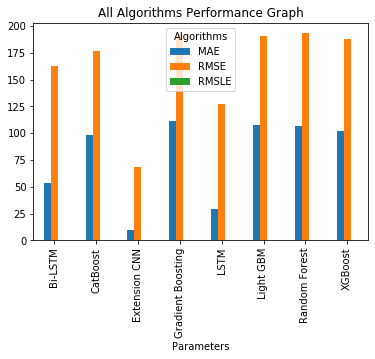

In [152]:
#plot all algorithm performance
df = pd.DataFrame([['Random Forest','MAE',mae[0]],['Random Forest','RMSE',rmse[0]],['Random Forest','RMSLE',rmsle[0]],
                   ['Gradient Boosting','MAE',mae[1]],['Gradient Boosting','RMSE',rmse[1]],['Gradient Boosting','RMSLE',rmsle[1]],
                   ['Light GBM','MAE',mae[2]],['Light GBM','RMSE',rmse[2]],['Light GBM','RMSLE',rmsle[2]],
                   ['CatBoost','MAE',mae[3]],['CatBoost','RMSE',rmse[3]],['CatBoost','RMSLE',rmsle[3]],
                   ['XGBoost','MAE',mae[4]],['XGBoost','RMSE',rmse[4]],['XGBoost','RMSLE',rmsle[4]],
                   ['LSTM','MAE',mae[5]],['LSTM','RMSE',rmse[5]],['LSTM','RMSLE',rmsle[5]],
                   ['Bi-LSTM','MAE',mae[6]],['Bi-LSTM','RMSE',rmse[6]],['Bi-LSTM','RMSLE',rmsle[6]],
                   ['Extension CNN','MAE',mae[7]],['Extension CNN','RMSE',rmse[7]],['Extension CNN','RMSLE',rmsle[7]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("All Algorithms Performance Graph")
plt.show()

In [153]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","MSE","RMSE", "RMSLE"]
values = []
algorithm_names = ["Random Forest","Gradient Boosting", "Light GBM","CatBoost", "XGBoost", "LSTM", "BI-LSTM","Extension CNN"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],mae[i],rmse[i], rmsle[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,MSE,RMSE,RMSLE
0,Random Forest,106.847025,193.153677,0.704723
1,Gradient Boosting,111.228799,191.948277,0.759446
2,Light GBM,107.335889,190.582220,0.697293
3,CatBoost,98.277249,176.999181,0.656369
4,XGBoost,101.924355,187.536650,0.691871
5,LSTM,29.706652,127.531458,0.435268
6,BI-LSTM,53.219438,162.826366,0.573238
7,Extension CNN,9.761380,68.732609,0.188711


In [154]:
dataset = pd.read_csv("Dataset/testData.csv")#read test data
dataset.fillna(0, inplace = True)
center = pd.read_csv("Dataset/fulfilment_center_info.csv")#read center type data
center.fillna(0, inplace = True)
dataset = dataset.merge(center, left_on = 'center_id', right_on = 'center_id', how="left")#merge both dataset
temp = dataset.values
dataset['center_type'] = pd.Series(le.transform(dataset['center_type'].astype(str)))#encode all str columns to numeric 
dataset.drop(['id'], axis = 1,inplace=True)
#extract training features from dataset and then normalize and split into train and test
X = dataset.values #get training features from dataset
X = sc1.transform(X)#normalize train features
X = np.reshape(X, (X.shape[0], X.shape[1], 1, 1))
predict = cnn_model.predict(X) #perfrom prediction on test data using extension model
predict = sc2.inverse_transform(predict)
predict = predict.ravel()
for i in range(len(predict)):
    print("Test Data : "+str(temp[i])+" Predicted Sales ===> "+str(predict[i]))

Test Data : [1151666 1 89 2640 281.33 280.33 0 0 703 56 'TYPE_A' 4.8] Predicted Sales ===> 205.91173
Test Data : [1048572 1 89 1878 282.33 280.33 0 0 703 56 'TYPE_A' 4.8] Predicted Sales ===> 289.71167
Test Data : [1379525 1 89 2306 243.5 242.5 0 1 703 56 'TYPE_A' 4.8] Predicted Sales ===> 556.96893
Test Data : [1152138 1 89 1216 456.93 454.93 0 1 703 56 'TYPE_A' 4.8] Predicted Sales ===> 412.3625
Test Data : [1478586 1 89 2126 487.0 485.0 0 0 703 56 'TYPE_A' 4.8] Predicted Sales ===> 68.18612
Test Data : [1092935 1 89 2826 341.44 342.44 0 0 703 56 'TYPE_A' 4.8] Predicted Sales ===> 129.0887
Test Data : [1090744 1 89 1754 284.27 283.27 0 0 703 56 'TYPE_A' 4.8] Predicted Sales ===> 300.8519
